In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Creating parameters to sample ranges for testing the impact of $k_{on}$ and $k_{add}$


In [24]:
import pandas as pd
import numpy as np

# Fixed burst probability

# Column headers
columns = [
    "k_on", "k_off", "mrna_half_life", "protein_half_life",
    "k_prod_mRNA", "k_prod_protein", "n_gene_1_to_gene_2",
    "k_add_gene_1_to_gene_2", "pair_id", "gene_id", "burst_frac"
]

# Fixed values for gene_1
base_gene_1 = [
    0.66,
    8.6,
    4, 45, 2, 560, 2, 6,  # k_add placeholder
    0, 1, 0.07
]

# Base template for gene_2 (will be overwritten)
base_gene_2 = [
    0.66, 0.0, 5, 45, 2, 560, 2, 0.0,  # k_add will be updated
    0, 2, 0
]

# Grid sampling
burst_prob_values = np.logspace(np.log10(0.002), np.log10(0.4), 10) 
k_add_k_on_ratio =  np.logspace(np.log10(0.5), np.log10(50), 10)
# k_add_k_on_ratio =  np.linspace(0.5, 50)
burst_prob_values = np.append(burst_prob_values, 0.07)

rows = []
pair_id = 0

for burst_prob in burst_prob_values:
    k_on = 0.66
    k_off =((1 /burst_prob) - 1)*k_on
    if k_off > 55 or k_off < 0.06:
        continue
    for k_add_ratio in k_add_k_on_ratio:
        if burst_prob == 0.07:
            k = 20
        else:
            k = 20
        for i in range(k):
            # Gene 1 (fixed, except pair_id)
            gene_1 = base_gene_1.copy()
            k_on = gene_1[0]
            k_add = k_add_ratio*k_on
            gene_1[7] = k_add
            gene_1[8] = pair_id  # pair_id
            gene_1[-1] = burst_prob
            # Gene 2 (grid-sampled)
            gene_2 = base_gene_2.copy()
            gene_2[1] = k_off
            gene_2[7] = k_add
            gene_2[8] = pair_id  # pair_id
            gene_2[-1] = burst_prob
            rows.append(gene_1)
            rows.append(gene_2)

            pair_id += 1

# Convert and save
df = pd.DataFrame(rows, columns=columns)
df.to_csv("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/k_add_simulations/simulation_details/effect_of_k_add_sampling_positive_with_reps.csv")


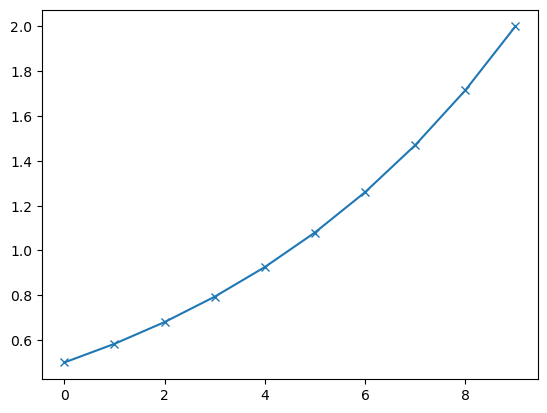

In [31]:
plt.plot(range(len(k_add_k_on_ratio)), k_add_k_on_ratio, marker = "x")
# plt.axhline(10)
plt.show()

In [36]:
import pandas as pd
import numpy as np

# Fixed burst probability

# Column headers
columns = [
    "k_on", "k_off", "mrna_half_life", "protein_half_life",
    "k_prod_mRNA", "k_prod_protein", "n_gene_1_to_gene_2",
    "k_add_gene_1_to_gene_2", "pair_id", "gene_id", "burst_frac"
]

# Fixed values for gene_1
base_gene_1 = [
    0.66,
    8.6,
    4, 45, 2, 560, 2, 6,  # k_add placeholder
    0, 1, 0.07
]

# Base template for gene_2 (will be overwritten)
base_gene_2 = [
    0.66, 0.0, 5, 45, 2, 560, 2, 0.0,  # k_add will be updated
    0, 2, 0
]

# Grid sampling
burst_prob_values = np.logspace(np.log10(0.002), np.log10(0.4), 10)
k_add_k_on_ratio = np.logspace(np.log10(0.5), np.log10(5), 10)
burst_prob_values = np.append(burst_prob_values, 0.07)

rows = []
pair_id = 0

for burst_prob in burst_prob_values:
     
    k_off =((1 /burst_prob) - 1)*k_on
    if k_off > 55 or k_off < 0.06:
        continue
    for k_add_ratio in k_add_k_on_ratio:
        for i in range(20):
            # Gene 1 (fixed, except pair_id)
            gene_1 = base_gene_1.copy()
            k_on = gene_1[0]
            k_add = k_add_ratio*k_on
            gene_1[7] = k_add
            gene_1[8] = pair_id  # pair_id
            gene_1[-1] = burst_prob
            # Gene 2 (grid-sampled)
            gene_2 = base_gene_2.copy()
            gene_2[1] = k_off
            gene_2[7] = k_add
            gene_2[8] = pair_id  # pair_id
            gene_2[-1] = burst_prob
            rows.append(gene_1)
            rows.append(gene_2)

            pair_id += 1

# Convert and save
df = pd.DataFrame(rows, columns=columns)

df.to_csv("/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/k_add_simulations/simulation_details/effect_of_k_add_sampling_repression_with_reps.csv")
